Student Dropout — Exploratory Data Analysis

This notebook performs a comprehensive EDA on the Student Dropout dataset (~4,424 students, 34 features).

**Goal:** Understand class distribution, feature relationships, and identify key predictors of student dropout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = pd.read_csv('../data/raw/dataset.csv')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)
display(df.isnull().sum())
display(df.describe())

Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int64
Age at enrollm

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## 1. Class Distribution

We examine the balance of the three target classes: **Dropout**, **Graduate**, and **Enrolled**.
If Dropout represents less than ~33% of the data, the dataset is imbalanced and we may need to account for this in modelling.

          Count  Percentage
Target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95


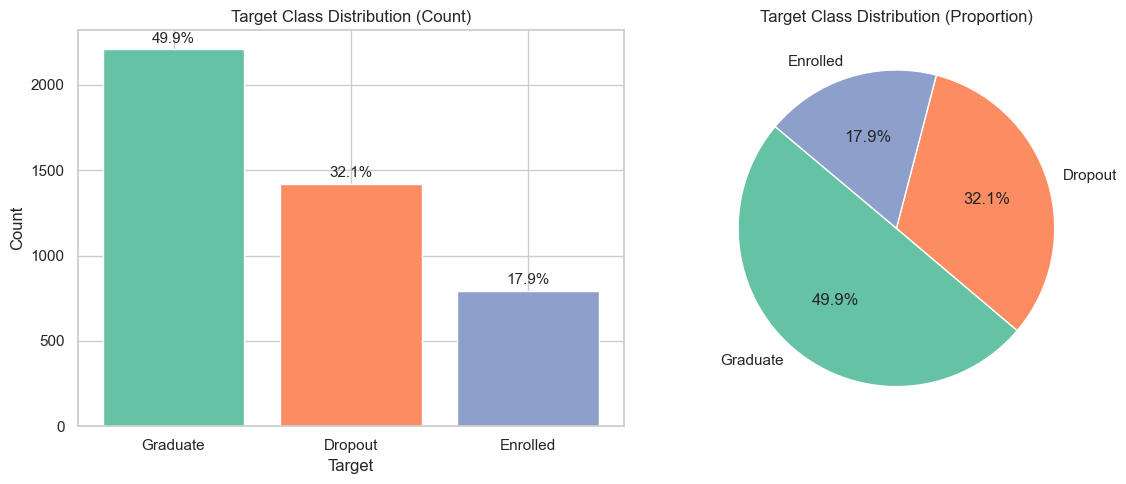

Dropout is 32.1% of the dataset — below 33%, indicating class imbalance.


In [2]:
counts = df['Target'].value_counts()
pcts = df['Target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percentage': pcts.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(counts.index, counts.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Target Class Distribution (Count)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3), startangle=140)
axes[1].set_title('Target Class Distribution (Proportion)')

plt.tight_layout()
plt.show()

dropout_pct = pcts.get('Dropout', 0)
if dropout_pct < 33:
    print(f'Dropout is {dropout_pct:.1f}% of the dataset — below 33%, indicating class imbalance.')
else:
    print(f'Dropout is {dropout_pct:.1f}% of the dataset — roughly balanced.')

## 2. Feature Bucketing

We group the 34 features into four thematic buckets for structured analysis:
- **Academic**: Curricular unit performance across both semesters
- **Demographic**: Student background and personal attributes
- **Financial**: Debt, tuition, and scholarship status
- **Macroeconomic**: External economic indicators at enrollment time

In [3]:
ACADEMIC = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]
DEMOGRAPHIC = [
    'Age at enrollment', 'Gender', 'Marital status', 'Nacionality',
    'International', 'Displaced', 'Educational special needs'
]
FINANCIAL = ['Debtor', 'Tuition fees up to date', 'Scholarship holder']
MACRO = ['Unemployment rate', 'Inflation rate', 'GDP']

buckets = {'ACADEMIC': ACADEMIC, 'DEMOGRAPHIC': DEMOGRAPHIC, 'FINANCIAL': FINANCIAL, 'MACRO': MACRO}
for name, feats in buckets.items():
    print(f'{name} ({len(feats)} features):')
    for f in feats:
        print(f'  - {f}')
    print()

ACADEMIC (12 features):
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)

DEMOGRAPHIC (7 features):
  - Age at enrollment
  - Gender
  - Marital status
  - Nacionality
  - International
  - Displaced
  - Educational special needs

FINANCIAL (3 features):
  - Debtor
  - Tuition fees up to date
  - Scholarship holder

MACRO (3 features):
  - Unemployment rate
  - Inflation rate
  - GDP



## 3. Correlation Analysis per Bucket

### 3a. Academic Features — Correlation Heatmap

We encode Target numerically (Dropout=0, Enrolled=1, Graduate=2) and compute pairwise correlations among academic features and the encoded target.

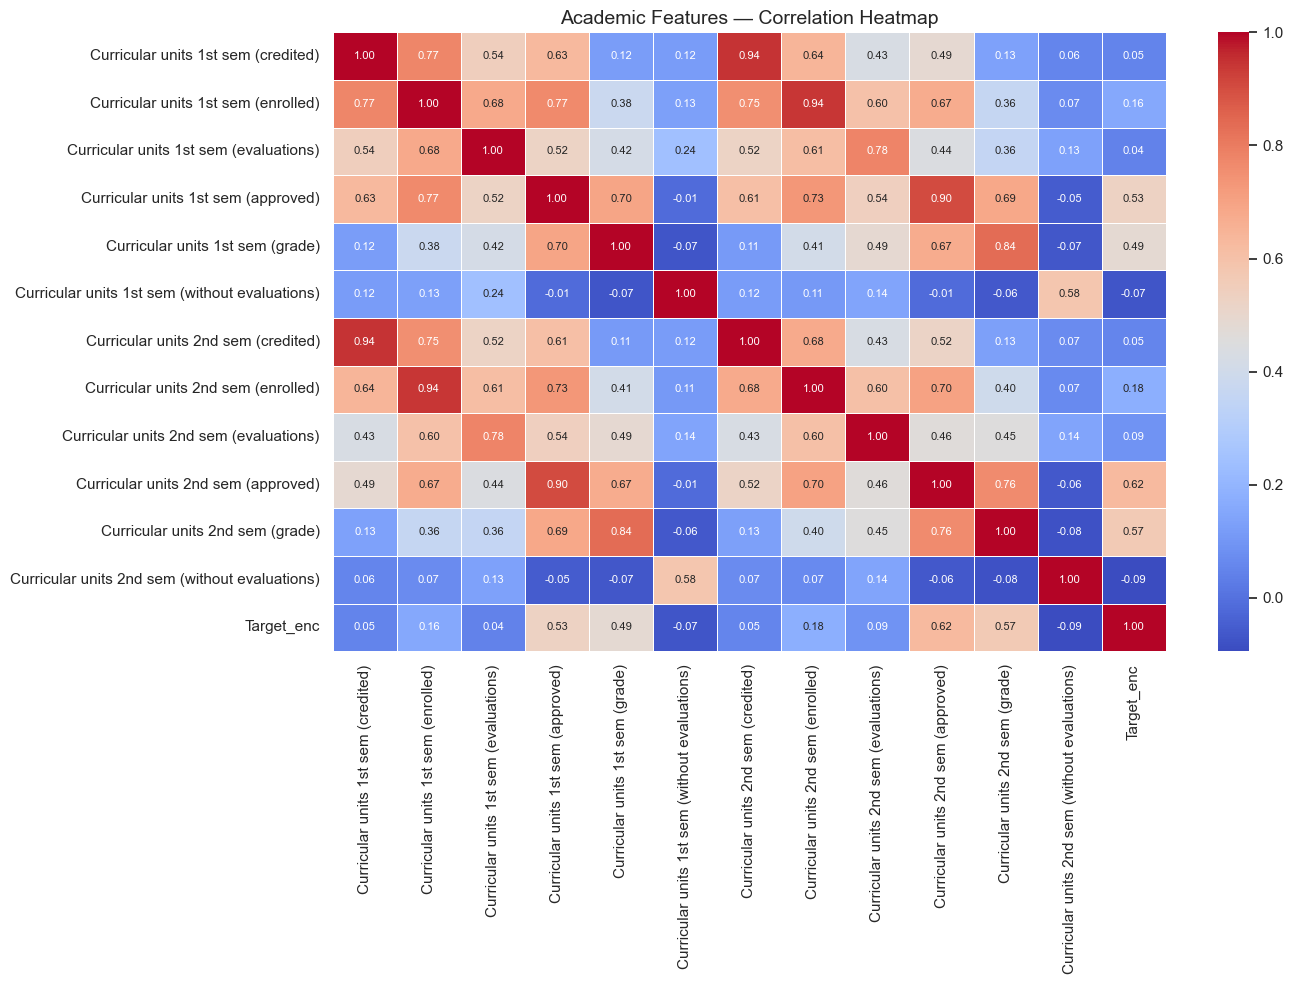

In [4]:
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_enc'] = df['Target'].map(target_map)

corr_academic = df[ACADEMIC + ['Target_enc']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_academic, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Academic Features — Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### 3b. Academic — Distribution by Target (Violin Plots)

Violin plots for the four key grade/approved columns split by Target class reveal how performance distributions differ between Dropout, Enrolled, and Graduate students.

C:\Users\nirmi\AppData\Local\Temp\ipykernel_22360\50501333.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Target', y=col, ax=axes[i], palette='Set2', inner='quartile')
C:\Users\nirmi\AppData\Local\Temp\ipykernel_22360\50501333.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Target', y=col, ax=axes[i], palette='Set2', inner='quartile')
C:\Users\nirmi\AppData\Local\Temp\ipykernel_22360\50501333.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Target', y=col, ax=axes[i], palette='Set2'

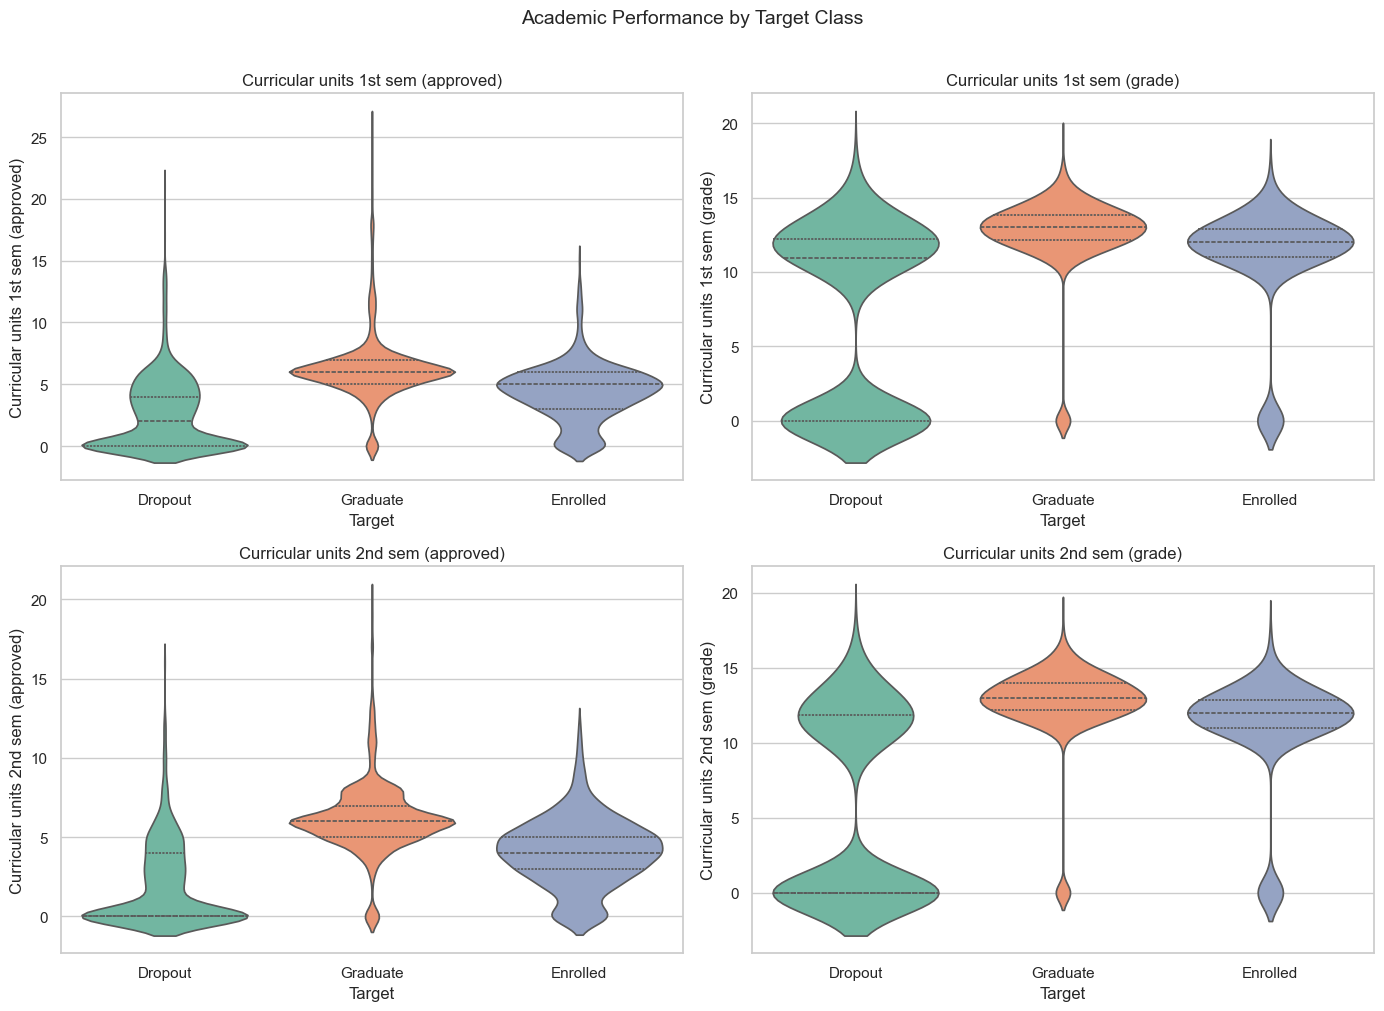

In [5]:
key_academic = [
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_academic):
    sns.violinplot(data=df, x='Target', y=col, ax=axes[i], palette='Set2', inner='quartile')
    axes[i].set_title(col)
    axes[i].set_xlabel('Target')

plt.suptitle('Academic Performance by Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Demographic — Grouped Bar Charts

For categorical demographic features (Gender, Marital status, Displaced, International), we show the normalized proportion of each Target class within each category value.

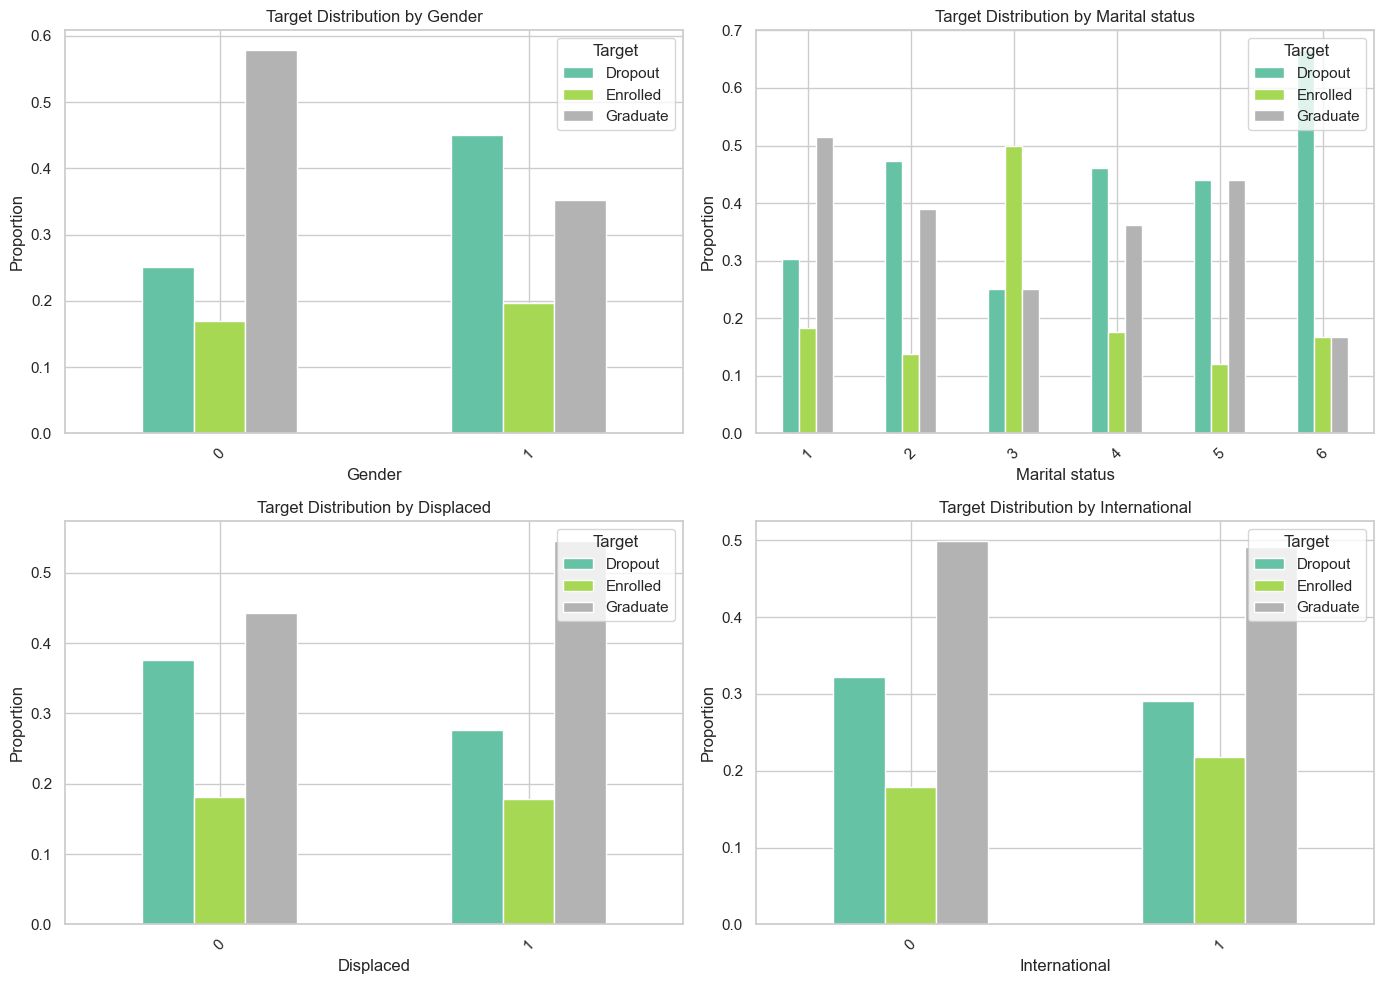

In [6]:
demo_cats = ['Gender', 'Marital status', 'Displaced', 'International']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(demo_cats):
    ct = pd.crosstab(df[col], df['Target'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Target Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Target', loc='upper right')

plt.tight_layout()
plt.show()

### 3d. Demographic — Age Distribution

KDE and boxplot of Age at enrollment by Target class to see if older students are more likely to drop out.

C:\Users\nirmi\AppData\Local\Temp\ipykernel_22360\826829587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Age at enrollment', ax=axes[1], palette='Set2')


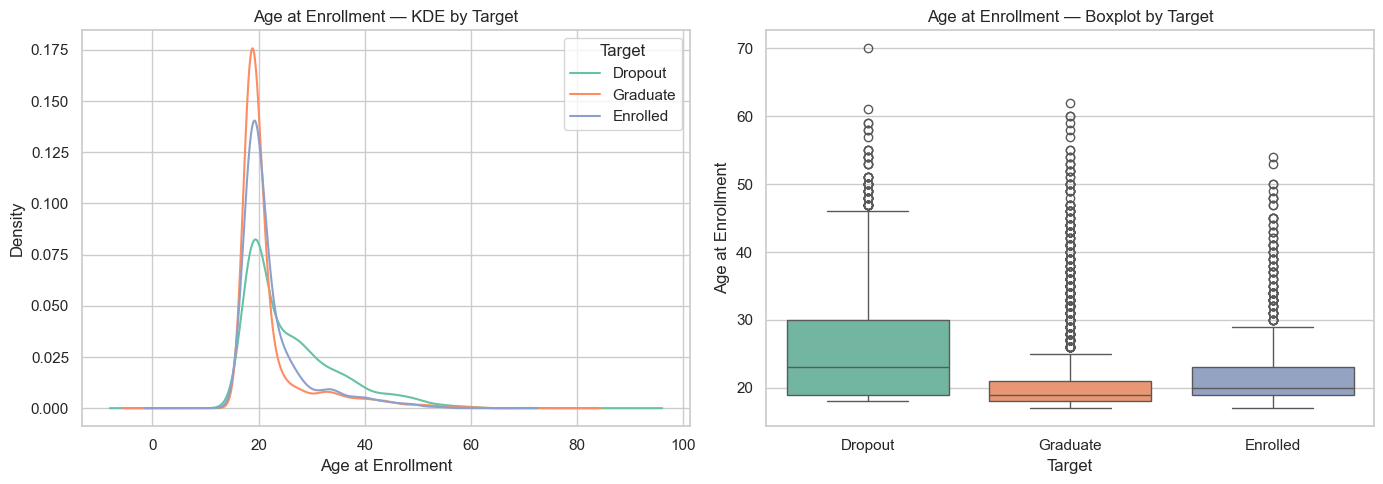

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_class in df['Target'].unique():
    subset = df[df['Target'] == target_class]['Age at enrollment']
    subset.plot.kde(ax=axes[0], label=target_class)
axes[0].set_title('Age at Enrollment — KDE by Target')
axes[0].set_xlabel('Age at Enrollment')
axes[0].legend(title='Target')

sns.boxplot(data=df, x='Target', y='Age at enrollment', ax=axes[1], palette='Set2')
axes[1].set_title('Age at Enrollment — Boxplot by Target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Age at Enrollment')

plt.tight_layout()
plt.show()

### 3e. Financial — Grouped Bar Charts

Normalized proportions of Target classes for Debtor, Tuition fees up to date, and Scholarship holder.

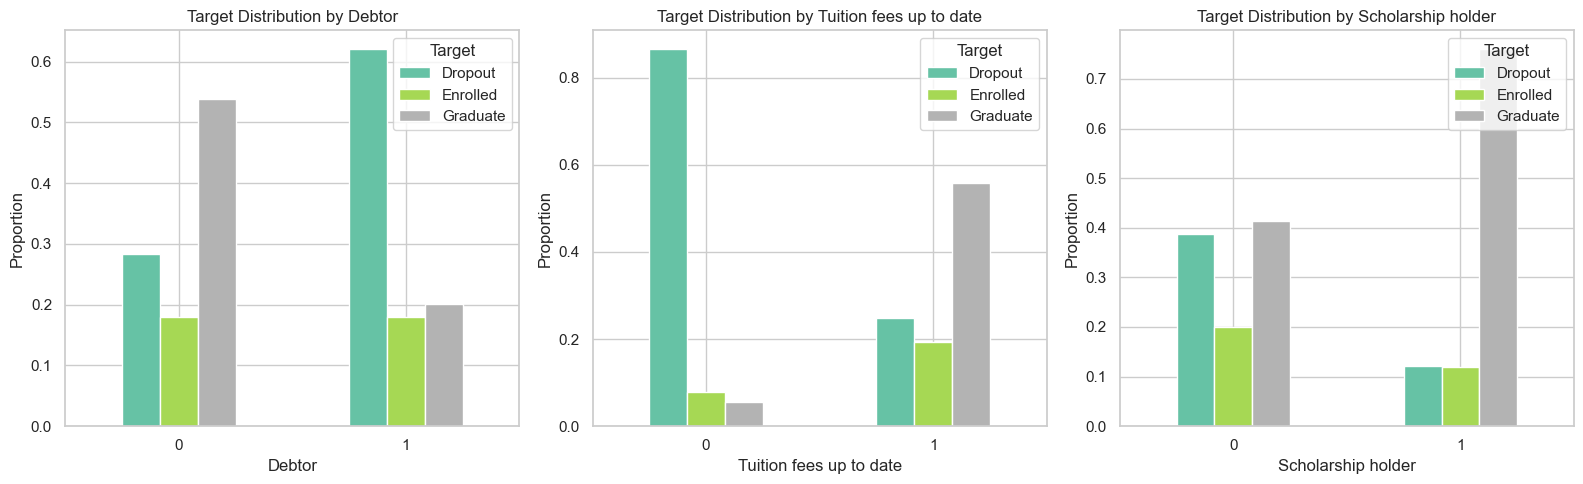

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(FINANCIAL):
    ct = pd.crosstab(df[col], df['Target'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Target Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Target', loc='upper right')

plt.tight_layout()
plt.show()

### 3f. Macroeconomic — KDE + Correlation

KDE distributions of Unemployment rate, Inflation rate, and GDP per Target class, plus correlation with the encoded target.

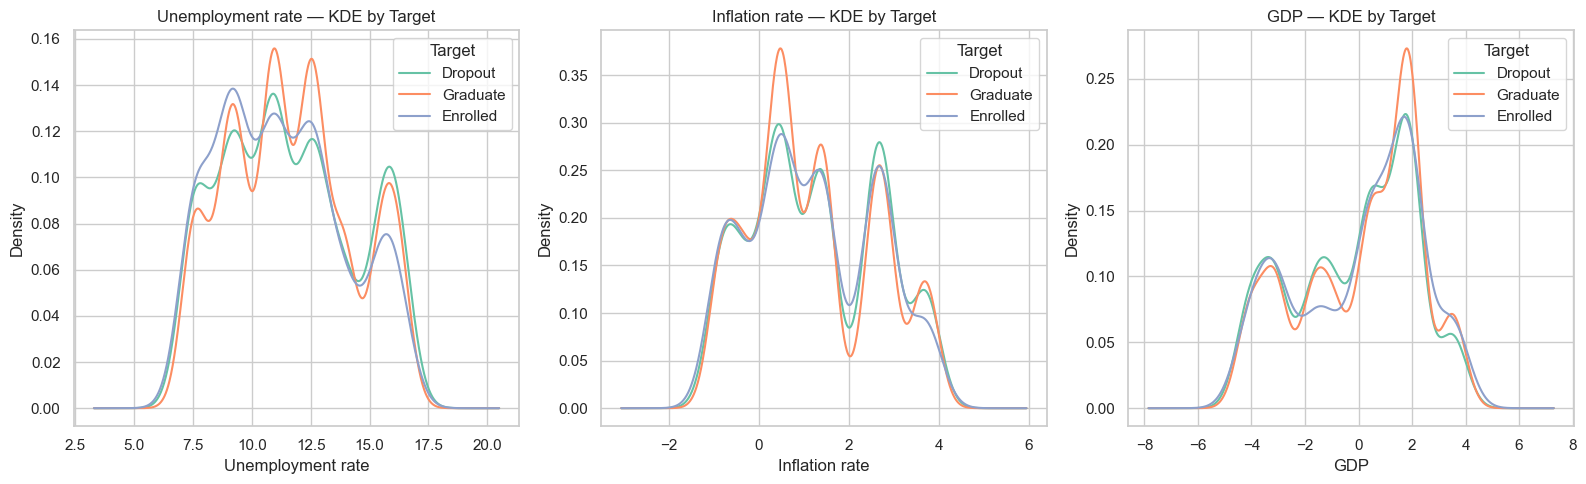

Correlation of Macro features with Target_enc:
  Unemployment rate: 0.0086
  Inflation rate: -0.0269
  GDP: 0.0441


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(MACRO):
    for target_class in df['Target'].unique():
        subset = df[df['Target'] == target_class][col]
        subset.plot.kde(ax=axes[i], label=target_class)
    axes[i].set_title(f'{col} — KDE by Target')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Target')

plt.tight_layout()
plt.show()

print('Correlation of Macro features with Target_enc:')
for col in MACRO:
    r = df[col].corr(df['Target_enc'])
    print(f'  {col}: {r:.4f}')

## 4. Hypothesis Testing

### Hypothesis 1: Students with 0 approved units in BOTH semesters almost always drop out

Zero-unit cohort size: 676 (15.3% of total)

Target distribution within zero-unit cohort:
Target
Dropout     80.77
Graduate    11.09
Enrolled     8.14
Name: proportion, dtype: float64


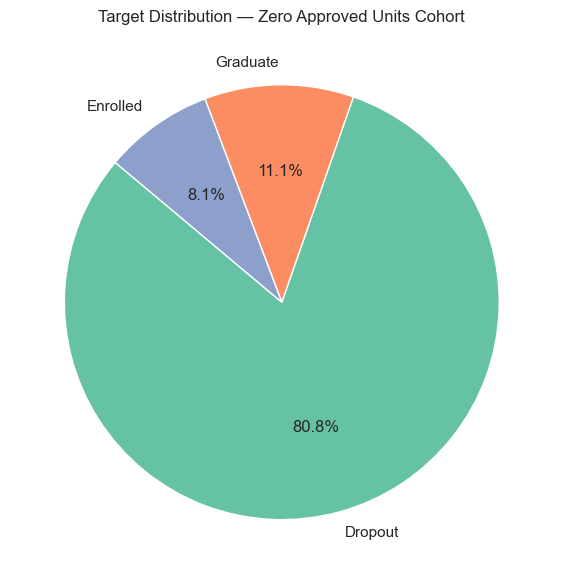

Overall dropout rate:          32.1%
Zero-unit cohort dropout rate: 80.8%


In [10]:
zero_cohort = df[
    (df['Curricular units 1st sem (approved)'] == 0) &
    (df['Curricular units 2nd sem (approved)'] == 0)
]

cohort_size = len(zero_cohort)
cohort_pct = cohort_size / len(df) * 100
print(f'Zero-unit cohort size: {cohort_size} ({cohort_pct:.1f}% of total)')
print()
print('Target distribution within zero-unit cohort:')
print((zero_cohort['Target'].value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 6))
zc_counts = zero_cohort['Target'].value_counts()
ax.pie(zc_counts.values, labels=zc_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(zc_counts)), startangle=140)
ax.set_title('Target Distribution — Zero Approved Units Cohort')
plt.tight_layout()
plt.show()

overall_dropout = (df['Target'] == 'Dropout').mean() * 100
cohort_dropout = (zero_cohort['Target'] == 'Dropout').mean() * 100
print(f'Overall dropout rate:          {overall_dropout:.1f}%')
print(f'Zero-unit cohort dropout rate: {cohort_dropout:.1f}%')

### Hypothesis 2: Being a Debtor AND having Tuition fees not up to date strongly correlates with Dropout

At-risk group counts:
at_risk
False    4178
True      246
Name: count, dtype: int64

At-risk     dropout rate: 87.4% (n=246)
Not at-risk dropout rate: 28.9% (n=4178)


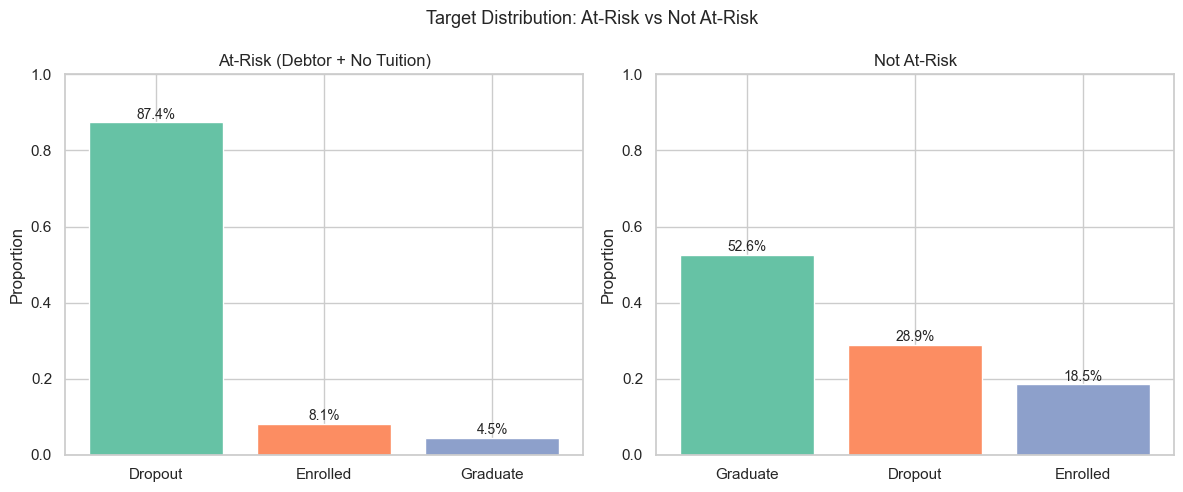

Odds ratio for Dropout (at-risk vs not): 17.09


In [11]:
at_risk = (df['Debtor'] == 1) & (df['Tuition fees up to date'] == 0)
df['at_risk'] = at_risk

print('At-risk group counts:')
print(df['at_risk'].value_counts())
print()

for flag in [True, False]:
    subset = df[df['at_risk'] == flag]
    dropout_rate = (subset['Target'] == 'Dropout').mean() * 100
    label = 'At-risk    ' if flag else 'Not at-risk'
    print(f'{label} dropout rate: {dropout_rate:.1f}% (n={len(subset)})')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (flag, label) in enumerate([(True, 'At-Risk (Debtor + No Tuition)'), (False, 'Not At-Risk')]):
    ct = df[df['at_risk'] == flag]['Target'].value_counts(normalize=True)
    colors = sns.color_palette('Set2', len(ct))
    axes[i].bar(ct.index, ct.values, color=colors)
    axes[i].set_title(label)
    axes[i].set_ylabel('Proportion')
    axes[i].set_ylim(0, 1)
    for j, (cls, val) in enumerate(ct.items()):
        axes[i].text(j, val + 0.01, f'{val:.1%}', ha='center', fontsize=10)

plt.suptitle('Target Distribution: At-Risk vs Not At-Risk', fontsize=13)
plt.tight_layout()
plt.show()

p_dropout_atrisk = (df[df['at_risk'] == True]['Target'] == 'Dropout').mean()
p_dropout_not = (df[df['at_risk'] == False]['Target'] == 'Dropout').mean()
odds_atrisk = p_dropout_atrisk / (1 - p_dropout_atrisk)
odds_not = p_dropout_not / (1 - p_dropout_not)
odds_ratio = odds_atrisk / odds_not
print(f'Odds ratio for Dropout (at-risk vs not): {odds_ratio:.2f}')

## 5. Additional EDA (Bonus)

### 5a. Missing Values & Data Quality

In [12]:
print('Missing values per column:')
display(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nFull statistical summary:')
display(df.describe())

Missing values per column:


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u


Duplicate rows: 0

Full statistical summary:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_enc
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,1.178119
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.888243
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,1.000000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,2.000000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,2.000000


### Application Mode and Course — do certain entry paths lead to more dropouts?

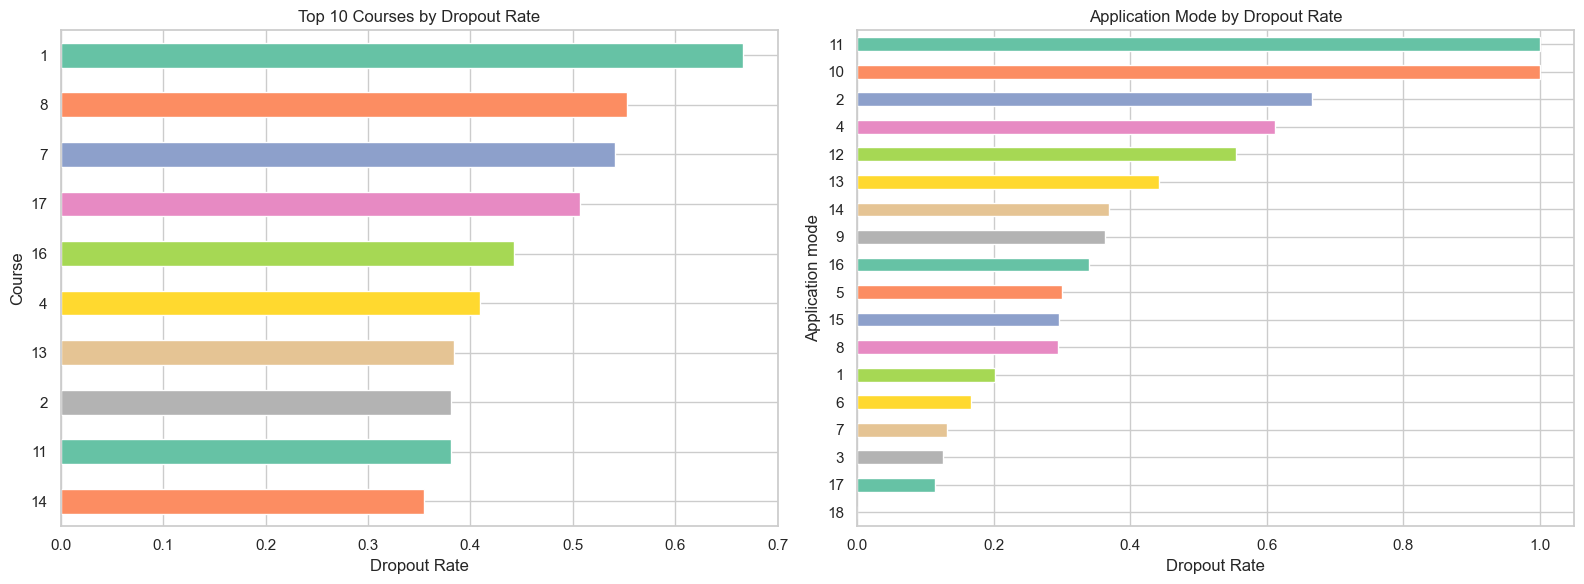

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

course_dropout = (
    df.groupby('Course')['Target']
    .apply(lambda x: (x == 'Dropout').mean())
    .sort_values(ascending=False)
    .head(10)
)
course_dropout.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', 10))
axes[0].set_title('Top 10 Courses by Dropout Rate')
axes[0].set_xlabel('Dropout Rate')
axes[0].invert_yaxis()

app_dropout = (
    df.groupby('Application mode')['Target']
    .apply(lambda x: (x == 'Dropout').mean())
    .sort_values(ascending=False)
)
app_dropout.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2', len(app_dropout)))
axes[1].set_title('Application Mode by Dropout Rate')
axes[1].set_xlabel('Dropout Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Outlier Detection — Age at enrollment and grade features

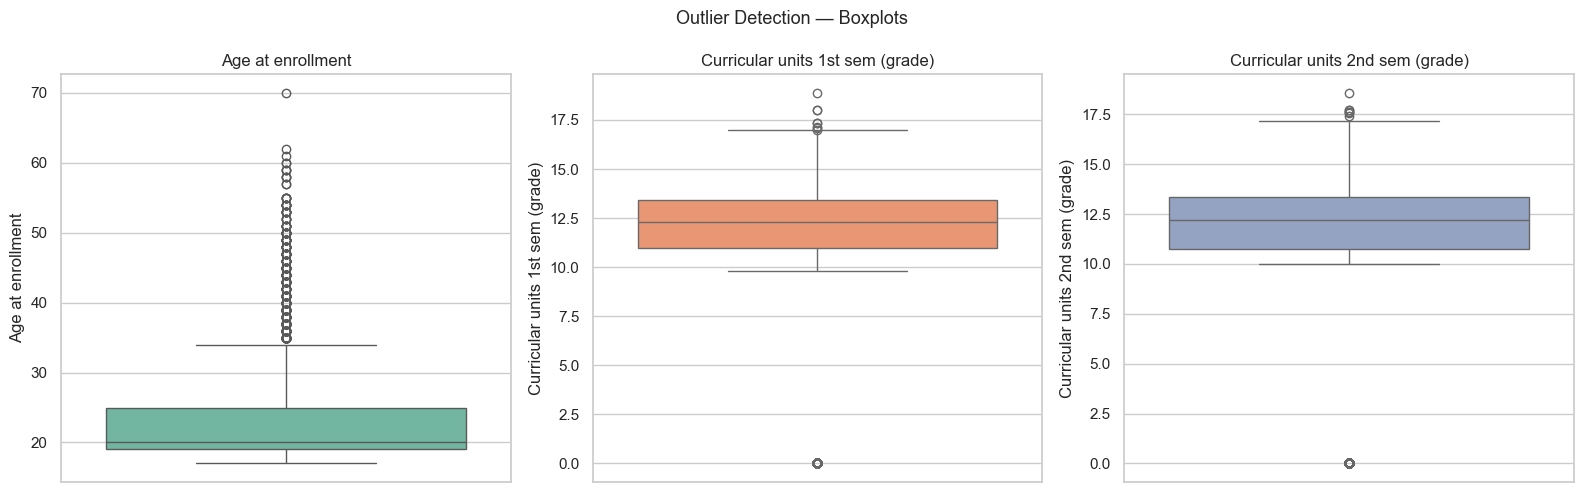

IQR-based outlier counts:
  Age at enrollment: 441 outliers (10.0%)
  Curricular units 1st sem (grade): 726 outliers (16.4%)
  Curricular units 2nd sem (grade): 877 outliers (19.8%)


In [14]:
outlier_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette('Set2')[i])
    axes[i].set_title(col)

plt.suptitle('Outlier Detection — Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

print('IQR-based outlier counts:')
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col}: {n_out} outliers ({n_out / len(df) * 100:.1f}%)')

### 5d. Pairplot — Academic Features vs Target

A pairplot of the four key academic features coloured by Target class. Note: this may take a moment to render.

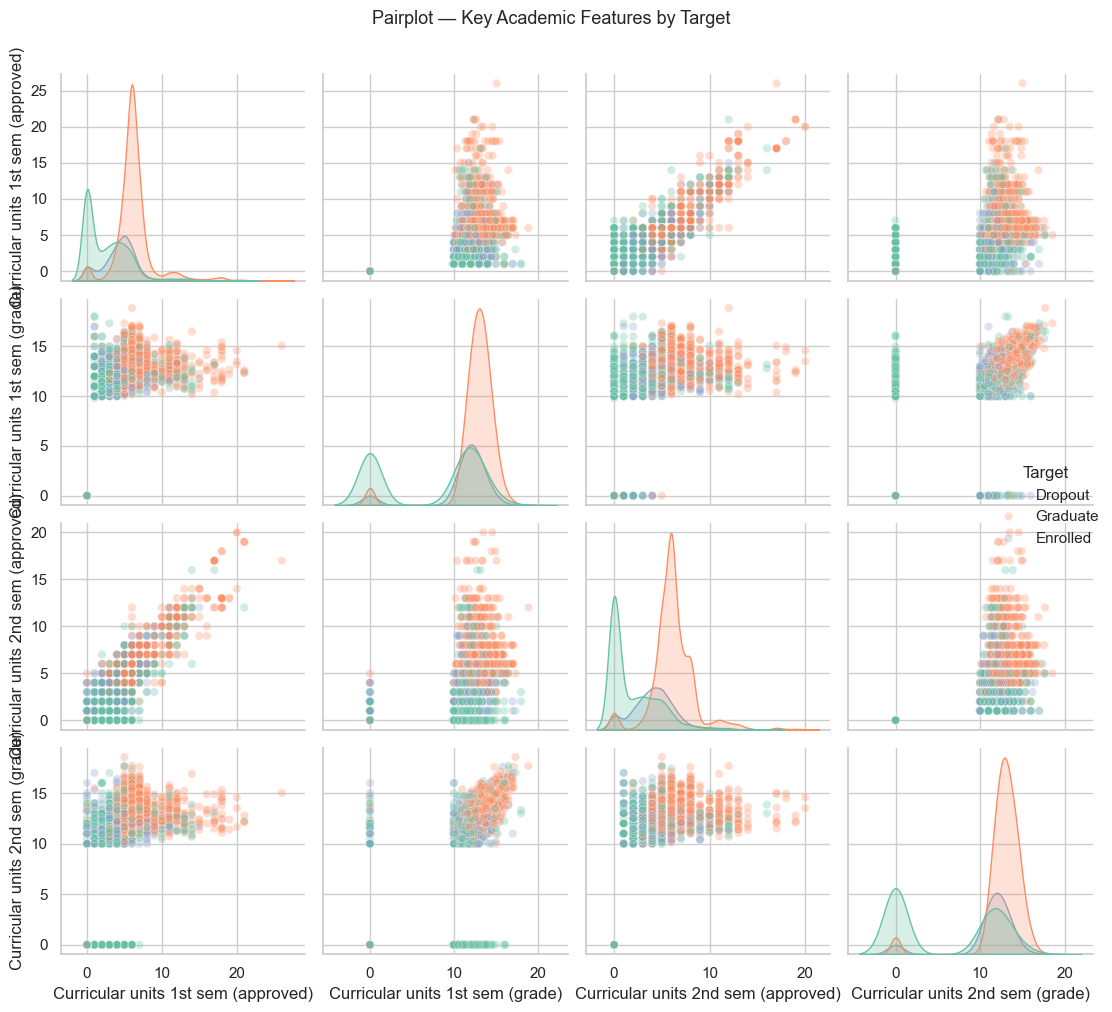

In [15]:
pairplot_cols = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Target'
]

g = sns.pairplot(
    df[pairplot_cols],
    hue='Target',
    palette='Set2',
    plot_kws=dict(alpha=0.3)
)
g.fig.suptitle('Pairplot — Key Academic Features by Target', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()